In [133]:
pip install pandas openpyxl matplotlib statsmodels scipy geopandas geodatasets contextily

In [134]:
# ── Study area map — 3-panel figure ──────────────────────────────────────────
# Requirements:
# pip install geopandas geodatasets contextily matplotlib shapely

import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch
from shapely.geometry import Point, box
import numpy as np

# ── Site coordinates ──────────────────────────────────────────────────────────
LAT, LON = 23.94821, 90.27727
site_gdf = gpd.GeoDataFrame(
    {"name": ["DEPZ Monitoring Station"]},
    geometry=[Point(LON, LAT)],
    crs="EPSG:4326"
).to_crs(epsg=3857)

In [ ]:
# ── Study area map — 3-panel figure ──────────────────────────────────────────
# Requirements:
# pip install geopandas geodatasets contextily matplotlib shapely

import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch
from shapely.geometry import Point, box
import numpy as np

# ── Site coordinates ──────────────────────────────────────────────────────────
LAT, LON = 23.94821, 90.27727
site_gdf = gpd.GeoDataFrame(
    {"name": ["DEPZ Monitoring Station"]},
    geometry=[Point(LON, LAT)],
    crs="EPSG:4326"
).to_crs(epsg=3857)

In [139]:
# ── Interactive study area map — renders inside Colab ─────────────────────────
# pip install folium  (already installed if you ran the earlier map code)

import folium
from folium import plugins

LAT, LON = 23.94821, 90.27727

# ── Base map ──────────────────────────────────────────────────────────────────
m = folium.Map(
    location=[LAT, LON],
    zoom_start=12,
    tiles=None,           # we add layers manually
    width="100%",
    height=550,
)

# ── Tile layers (user can toggle) ─────────────────────────────────────────────
folium.TileLayer(
    "CartoDB positron",
    name="Street map (light)",
    control=True
).add_to(m)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/"
          "World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
    name="Satellite",
    control=True
).add_to(m)

folium.TileLayer(
    "OpenStreetMap",
    name="OpenStreetMap",
    control=True
).add_to(m)

# ── DEPZ station marker ───────────────────────────────────────────────────────
folium.Marker(
    location=[LAT, LON],
    tooltip="DEPZ Air Quality Monitoring Station",
    popup=folium.Popup(
        f"""
        <div style='font-family:Arial;font-size:13px;min-width:220px'>
          <b style='font-size:15px;color:#e63946'>DEPZ Monitoring Station</b><br>
          <hr style='margin:6px 0'>
          <b>Location:</b> Dhaka Export Processing Zone<br>
          <b>Latitude:</b> {LAT}°N<br>
          <b>Longitude:</b> {LON}°E<br>
          <b>Data period:</b> 2019–2023<br>
          <b>Pollutants:</b> PM2.5, PM10, CO<br>
          <hr style='margin:6px 0'>
          <span style='color:#888;font-size:11px'>
            Click layers icon (top right) to switch basemap
          </span>
        </div>
        """,
        max_width=280,
    ),
    icon=folium.Icon(
        color="red",
        icon="industry",
        prefix="fa"
    ),
).add_to(m)

# ── Radius rings — 5 km and 10 km ────────────────────────────────────────────
folium.Circle(
    location=[LAT, LON],
    radius=5000,
    color="#e63946",
    weight=1.5,
    fill=False,
    tooltip="5 km radius",
    dash_array="6 4",
).add_to(m)

folium.Circle(
    location=[LAT, LON],
    radius=10000,
    color="#e63946",
    weight=1,
    fill=False,
    tooltip="10 km radius",
    dash_array="3 6",
    opacity=0.5,
).add_to(m)

# ── Dhaka city centre marker (context) ───────────────────────────────────────
folium.Marker(
    location=[23.8103, 90.4125],
    tooltip="Dhaka city centre (~10 km from DEPZ)",
    icon=folium.Icon(color="blue", icon="city", prefix="fa"),
    popup=folium.Popup("Dhaka City Centre", max_width=150),
).add_to(m)

# ── Mini-map ──────────────────────────────────────────────────────────────────
plugins.MiniMap(
    toggle_display=True,
    position="bottomright",
    zoom_level_offset=-6,
    tile_layer="CartoDB positron",
).add_to(m)

# ── Fullscreen button ─────────────────────────────────────────────────────────
plugins.Fullscreen(position="topright").add_to(m)

# ── Layer control ─────────────────────────────────────────────────────────────
folium.LayerControl(collapsed=False).add_to(m)

# ── Title overlay ─────────────────────────────────────────────────────────────
title_html = """
<div style="
    position:fixed; top:10px; left:50%; transform:translateX(-50%);
    z-index:9999; background:white; padding:8px 20px;
    border-radius:8px; border:1px solid #ddd;
    font-family:Arial; text-align:center;
    box-shadow:2px 2px 6px rgba(0,0,0,0.15)">
  <b style='font-size:14px;color:#1a1a2e'>
    Study Area — DEPZ, Bangladesh
  </b><br>
  <span style='font-size:11px;color:#888'>
    23.948°N, 90.277°E &nbsp;|&nbsp; Air Quality Monitoring Site
  </span>
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

# ── Display inside Colab ──────────────────────────────────────────────────────
from IPython.display import display
display(m)

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from scipy import stats

# Load
df_raw = pd.read_excel("/content/Data on Air Quality- DEPZ-Published-R1.xlsx", header=4)
df = df_raw[["Date (dd:mm)", "Year",
             "PM2.5 (µg/m3) (24hr)", "AQI",
             "PM10 (µg/m3) (24hr)",  "AQI.1",
             "CO (ppm) (8hr)",        "AQI.2"]].copy()

df.columns = ["date_raw","year","pm25","aqi_pm25","pm10","aqi_pm10","co","aqi_co"]
df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)

# Fix dates — Excel parsed all years as 2024, correct using Year column
df["month"] = pd.to_datetime(df["date_raw"]).dt.month
df["day"]   = pd.to_datetime(df["date_raw"]).dt.day
df["date"]  = pd.to_datetime(dict(year=df["year"], month=df["month"], day=df["day"]))
df = df.set_index("date").sort_index()

print(df[["pm25","pm10","co"]].describe().round(2))

         pm25    pm10     co
count   60.00   60.00  60.00
mean    49.10  167.60   9.03
std     36.03   94.19   3.21
min      9.10   41.00   3.30
25%     16.75   91.00   6.22
50%     34.95  166.00   9.20
75%     75.75  244.75  11.08
max    140.70  343.00  15.10


In [98]:
print(df.head())

             date_raw  year   pm25  aqi_pm25  pm10  aqi_pm10    co  aqi_co  \
date                                                                         
2019-01-06 2024-01-06  2019   45.7       126   294       170  13.0     159   
2019-02-18 2024-02-18  2019   68.3       158   290       168  14.5     185   
2019-03-07 2024-03-07  2019  121.3       185   323       185  11.0     126   
2019-04-21 2024-04-21  2019   98.5       173   196       121   9.0      96   
2019-05-15 2024-05-15  2019   44.7       124   167       107   7.0      76   

            month  day  
date                    
2019-01-06      1    6  
2019-02-18      2   18  
2019-03-07      3    7  
2019-04-21      4   21  
2019-05-15      5   15  


In [99]:
display(df)

,date_raw,year,pm25,aqi_pm25,pm10,aqi_pm10,co,aqi_co,month,day
date,,,,,,,,,,
2019-01-06,2024-01-06,2019,45.7,126,294,170,13.0,159,1,6
2019-02-18,2024-02-18,2019,68.3,158,290,168,14.5,185,2,18
2019-03-07,2024-03-07,2019,121.3,185,323,185,11.0,126,3,7
2019-04-21,2024-04-21,2019,98.5,173,196,121,9.0,96,4,21
2019-05-15,2024-05-15,2019,44.7,124,167,107,7.0,76,5,15
2019-06-09,2024-06-09,2019,54.3,147,95,71,10.7,121,6,9
2019-07-12,2024-07-12,2019,10.3,43,46,43,7.0,76,7,12
2019-08-19,2024-08-19,2019,14.9,57,91,69,3.7,42,8,19
2019-09-03,2024-09-03,2019,20.5,69,107,77,12.0,143,9,3


In [100]:
print(df.shape)

(60, 10)


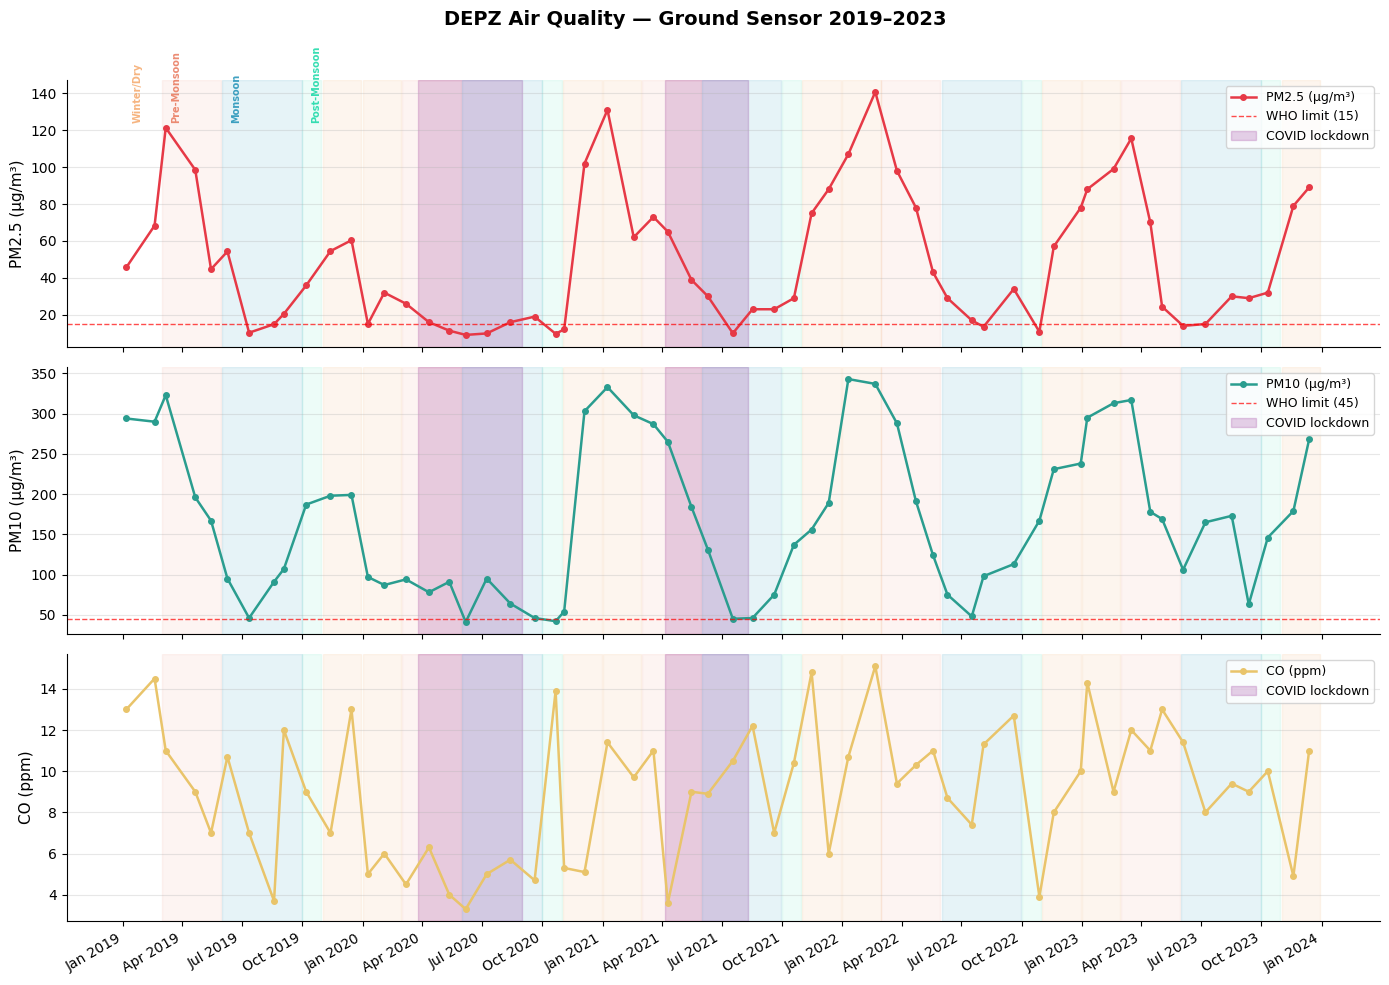

In [101]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("DEPZ Air Quality — Ground Sensor 2019–2023", fontsize=14, fontweight="bold")

pollutants = [("pm25", "PM2.5 (µg/m³)", "#e63946"),
              ("pm10", "PM10 (µg/m³)",  "#2a9d8f"),
              ("co",   "CO (ppm)",       "#e9c46a")]

who_limits = {"pm25": 15, "pm10": 45, "co": None}

# ── Bangladesh COVID lockdown phases (official) ──────────────────────────────
covid_periods = [
    ("2020-03-26", "2020-08-31"),   # 1st wave — strict + gradual easing
    ("2021-04-05", "2021-08-10"),   # 2nd wave — strict lockdown again
]

# ── Dhaka seasons (based on tropical wet/dry climate) ────────────────────────
seasons = {
    "Winter/Dry":    {"months": [11, 12,  1,  2], "color": "#f4a261", "alpha": 0.10},
    "Pre-Monsoon":   {"months": [ 3,  4,  5    ], "color": "#e76f51", "alpha": 0.07},
    "Monsoon":       {"months": [ 6,  7,  8,  9], "color": "#118ab2", "alpha": 0.10},
    "Post-Monsoon":  {"months": [10             ], "color": "#06d6a0", "alpha": 0.07},
}

for ax, (col, label, color) in zip(axes, pollutants):

    # — Raw data line ──────────────────────────────────────────────────────────
    ax.plot(df.index, df[col], color=color, linewidth=1.8,
            marker="o", markersize=4, label=label)

    # — WHO threshold ──────────────────────────────────────────────────────────
    if who_limits[col]:
        ax.axhline(who_limits[col], color="red", linestyle="--",
                   linewidth=1, alpha=0.7, label=f"WHO limit ({who_limits[col]})")

    # — COVID shading (both waves) ─────────────────────────────────────────────
    for i, (start, end) in enumerate(covid_periods):
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.18, color="purple",
                   label="COVID lockdown" if i == 0 else None)  # label once only

    # — Seasonal shading ───────────────────────────────────────────────────────
    for year in range(2019, 2024):
        for season_name, props in seasons.items():
            months = props["months"]

            # Group consecutive months into single spans
            if len(months) == 1:
                month_ranges = [(months[0], months[0])]
            elif months[0] == 11:
                # Winter crosses year boundary: Nov–Dec this year, Jan–Feb next year
                month_ranges = [(11, 12)]
                if year < 2023:
                    ax.axvspan(pd.Timestamp(f"{year+1}-01-01"),
                               pd.Timestamp(f"{year+1}-02-28"),
                               alpha=props["alpha"], color=props["color"])
            else:
                month_ranges = [(months[0], months[-1])]

            for m_start, m_end in month_ranges:
                try:
                    ax.axvspan(pd.Timestamp(f"{year}-{m_start:02d}-01"),
                               pd.Timestamp(f"{year}-{m_end:02d}-30"),
                               alpha=props["alpha"], color=props["color"])
                except Exception:
                    pass

    ax.set_ylabel(label, fontsize=11)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

# — Season legend annotation (top plot only) ──────────────────────────────────
season_labels = [
    ("Winter/Dry",   "#f4a261"),
    ("Pre-Monsoon",  "#e76f51"),
    ("Monsoon",      "#118ab2"),
    ("Post-Monsoon", "#06d6a0"),
]
y_pos = axes[0].get_ylim()[1] * 0.85
x_positions = [pd.Timestamp("2019-01-15"), pd.Timestamp("2019-03-15"),
               pd.Timestamp("2019-06-15"), pd.Timestamp("2019-10-15")]

for (name, clr), xpos in zip(season_labels, x_positions):
    axes[0].annotate(name, xy=(xpos, y_pos), fontsize=7,
                     color=clr, fontweight="bold", rotation=90, alpha=0.8)

# — X-axis formatting ──────────────────────────────────────────────────────────
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("01_timeseries_raw.png", dpi=150, bbox_inches="tight")
plt.show()

In [102]:
import requests
import pandas as pd

def get_nasa_power(lat, lon, start, end):
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "parameters": "T2M,T2M_MAX,T2M_MIN,RH2M,WS2M,PRECTOTCORR",
        "community": "RE",
        "longitude": lon,
        "latitude": lat,
        "start": start,   # "20190101"
        "end": end,        # "20231231"
        "format": "JSON"
    }
    r = requests.get(url, params=params)
    data = r.json()["properties"]["parameter"]
    df = pd.DataFrame(data)
    df.index = pd.to_datetime(df.index, format="%Y%m%d")
    return df

weather = get_nasa_power(23.94821, 90.27727, "20190101", "20231231")
weather.columns = ["temp_mean","temp_max","temp_min","humidity","wind_speed","rainfall"]
weather = weather.replace(-999, pd.NA)  # NASA uses -999 for missing

In [103]:
# Match each pollution reading to the weather on that exact date
df_merged = df.join(weather, how="left")

# ── verify all columns merged correctly ──────────────────────────────────────
print("Shape:", df_merged.shape)
print("\nAll columns:", df_merged.columns.tolist())
print("\nMissing values per column:")
print(df_merged.isnull().sum())

print("\nSample — pollution + weather together:")
print(df_merged[[
    "pm25", "pm10", "co",
    "temp_mean", "temp_min", "temp_max",
    "humidity", "wind_speed", "rainfall"
]].head(10).to_string())

print("\nDescriptive stats:")
print(df_merged[[
    "pm25", "pm10", "co",
    "temp_mean", "humidity", "wind_speed", "rainfall"
]].describe().round(2).to_string())

Shape: (60, 16)

All columns: ['date_raw', 'year', 'pm25', 'aqi_pm25', 'pm10', 'aqi_pm10', 'co', 'aqi_co', 'month', 'day', 'temp_mean', 'temp_max', 'temp_min', 'humidity', 'wind_speed', 'rainfall']

Missing values per column:
date_raw      0
year          0
pm25          0
aqi_pm25      0
pm10          0
aqi_pm10      0
co            0
aqi_co        0
month         0
day           0
temp_mean     0
temp_max      0
temp_min      0
humidity      0
wind_speed    0
rainfall      0
dtype: int64

Sample — pollution + weather together:
             pm25  pm10    co  temp_mean  temp_min  temp_max  humidity  wind_speed  rainfall
date                                                                                        
2019-01-06   45.7   294  13.0      19.11     12.61     26.20     56.22        0.85      0.00
2019-02-18   68.3   290  14.5      20.68     14.91     27.10     43.92        1.22      0.00
2019-03-07  121.3   323  11.0      24.81     18.52     30.01     47.73        0.91      0.00


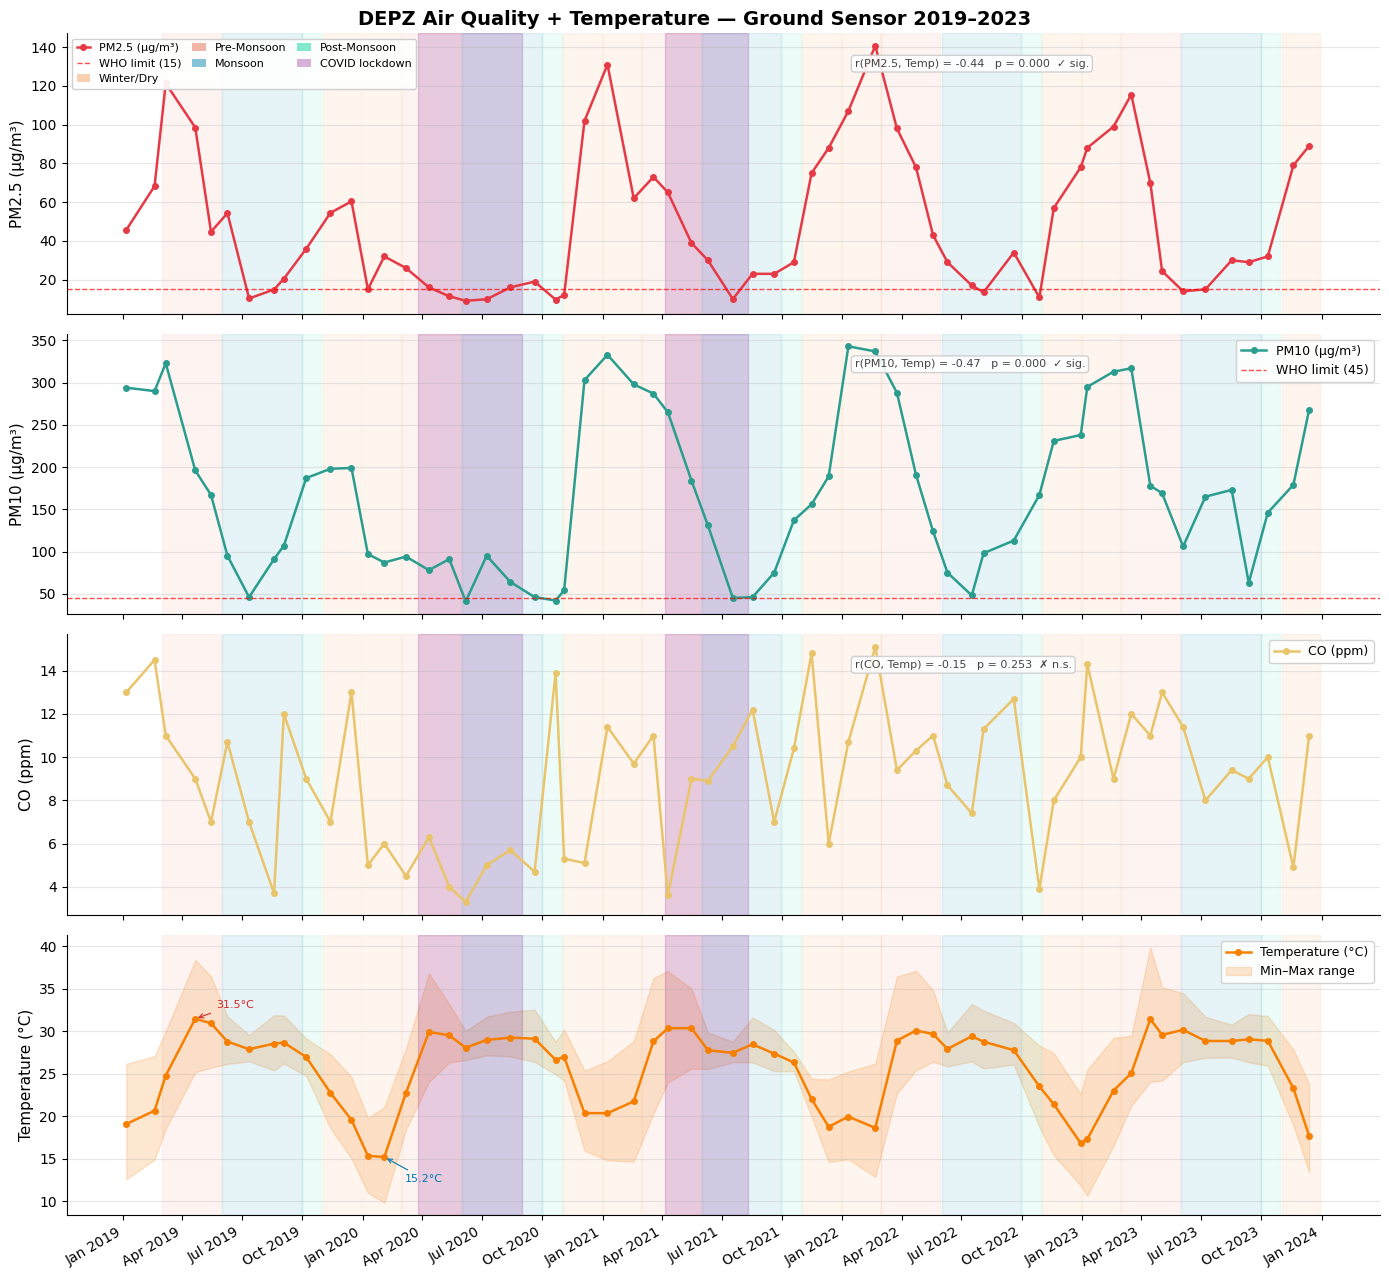

In [104]:
# ── Step 2 — Exploratory time series plot (all pollutants + temperature) ──────

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from scipy import stats

fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)
fig.suptitle("DEPZ Air Quality + Temperature — Ground Sensor 2019–2023",
             fontsize=14, fontweight="bold")

pollutants = [("pm25",      "PM2.5 (µg/m³)",   "#e63946"),
              ("pm10",      "PM10 (µg/m³)",    "#2a9d8f"),
              ("co",        "CO (ppm)",         "#e9c46a"),
              ("temp_mean", "Temperature (°C)", "#f77f00")]

who_limits = {"pm25": 15, "pm10": 45, "co": None, "temp_mean": None}

covid_periods = [
    ("2020-03-26", "2020-08-31"),
    ("2021-04-05", "2021-08-10"),
]

seasons = {
    "Winter/Dry":   {"months": [11, 12,  1,  2], "color": "#f4a261", "alpha": 0.10},
    "Pre-Monsoon":  {"months": [ 3,  4,  5    ], "color": "#e76f51", "alpha": 0.07},
    "Monsoon":      {"months": [ 6,  7,  8,  9], "color": "#118ab2", "alpha": 0.10},
    "Post-Monsoon": {"months": [10             ], "color": "#06d6a0", "alpha": 0.07},
}

for ax, (col, label, color) in zip(axes, pollutants):

    ax.plot(df_merged.index, df_merged[col], color=color, linewidth=1.8,
            marker="o", markersize=4, label=label)

    # — Temperature panel extras ───────────────────────────────────────────────
    if col == "temp_mean":
        ax.fill_between(df_merged.index,
                        df_merged["temp_min"], df_merged["temp_max"],
                        alpha=0.18, color=color, label="Min–Max range")
        coldest = df_merged["temp_mean"].idxmin()
        hottest = df_merged["temp_mean"].idxmax()
        ax.annotate(f"{df_merged.loc[coldest, 'temp_mean']:.1f}°C",
                    xy=(coldest, df_merged.loc[coldest, "temp_mean"]),
                    xytext=(15, -18), textcoords="offset points",
                    fontsize=8, color="#0077b6",
                    arrowprops=dict(arrowstyle="->", color="#0077b6", lw=0.8))
        ax.annotate(f"{df_merged.loc[hottest, 'temp_mean']:.1f}°C",
                    xy=(hottest, df_merged.loc[hottest, "temp_mean"]),
                    xytext=(15, 8), textcoords="offset points",
                    fontsize=8, color="#d62828",
                    arrowprops=dict(arrowstyle="->", color="#d62828", lw=0.8))

    # — WHO threshold ──────────────────────────────────────────────────────────
    if who_limits[col]:
        ax.axhline(who_limits[col], color="red", linestyle="--",
                   linewidth=1, alpha=0.7, label=f"WHO limit ({who_limits[col]})")

    # — COVID shading ──────────────────────────────────────────────────────────
    for start, end in covid_periods:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.18, color="purple", label=None)

    # — Seasonal shading ───────────────────────────────────────────────────────
    for year in range(2019, 2024):
        for season_name, props in seasons.items():
            months = props["months"]
            if len(months) == 1:
                month_ranges = [(months[0], months[0])]
            elif months[0] == 11:
                month_ranges = [(11, 12)]
                if year < 2023:
                    ax.axvspan(pd.Timestamp(f"{year+1}-01-01"),
                               pd.Timestamp(f"{year+1}-02-28"),
                               alpha=props["alpha"], color=props["color"])
            else:
                month_ranges = [(months[0], months[-1])]
            for m_start, m_end in month_ranges:
                try:
                    ax.axvspan(pd.Timestamp(f"{year}-{m_start:02d}-01"),
                               pd.Timestamp(f"{year}-{m_end:02d}-30"),
                               alpha=props["alpha"], color=props["color"])
                except Exception:
                    pass

    ax.set_ylabel(label, fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    # — Per-panel legend (panels 2–4 only) ────────────────────────────────────
    if col != "pm25":
        ax.legend(loc="upper right", fontsize=9,
                  framealpha=0.85, edgecolor="#cccccc")

# — Pearson r annotation — all three pollutant panels ────────────────────────
for ax_idx, col, name in [(0,"pm25","PM2.5"), (1,"pm10","PM10"), (2,"co","CO")]:
    clean = df_merged[[col, "temp_mean"]].dropna()
    if len(clean) < 3:
        continue
    r_val, p_val = stats.pearsonr(clean[col], clean["temp_mean"])
    sig = "✓ sig." if p_val < 0.05 else "✗ n.s."
    axes[ax_idx].annotate(
        f"r({name}, Temp) = {r_val:+.2f}   p = {p_val:.3f}  {sig}",
        xy=(0.60, 0.88), xycoords="axes fraction",
        fontsize=8, color="#444",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc", alpha=0.9),
    )

# — Combined legend for PM2.5 panel ───────────────────────────────────────────
existing_handles, existing_labels = axes[0].get_legend_handles_labels()

season_patches = [
    mpatches.Patch(facecolor="#f4a261", alpha=0.5, label="Winter/Dry"),
    mpatches.Patch(facecolor="#e76f51", alpha=0.5, label="Pre-Monsoon"),
    mpatches.Patch(facecolor="#118ab2", alpha=0.5, label="Monsoon"),
    mpatches.Patch(facecolor="#06d6a0", alpha=0.5, label="Post-Monsoon"),
    mpatches.Patch(facecolor="purple",  alpha=0.3, label="COVID lockdown"),
]

axes[0].legend(
    handles=existing_handles + season_patches,
    labels=existing_labels + [p.get_label() for p in season_patches],
    loc="upper left",
    bbox_to_anchor=(0.0, 1.0),
    ncol=3,
    fontsize=8,
    framealpha=0.92,
    edgecolor="#cccccc",
    handlelength=1.2,
    columnspacing=1.0,
)

# — X-axis ─────────────────────────────────────────────────────────────────────
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("01_timeseries_raw.png", dpi=150, bbox_inches="tight")
plt.show()

In [105]:
# ── Step 3 — STL Seasonal Decomposition ──────────────────────────────────────

from statsmodels.tsa.seasonal import STL

# Resample to monthly means — STL needs regular frequency
monthly = df_merged[[
    "pm25", "pm10", "co", "temp_mean"
]].resample("MS").mean()

print("Monthly resampled shape:", monthly.shape)
print(monthly.head(12).round(2).to_string())

Monthly resampled shape: (60, 4)
             pm25   pm10    co  temp_mean
date                                     
2019-01-01   45.7  294.0  13.0      19.11
2019-02-01   68.3  290.0  14.5      20.68
2019-03-01  121.3  323.0  11.0      24.81
2019-04-01   98.5  196.0   9.0      31.50
2019-05-01   44.7  167.0   7.0      30.96
2019-06-01   54.3   95.0  10.7      28.81
2019-07-01   10.3   46.0   7.0      27.91
2019-08-01   14.9   91.0   3.7      28.57
2019-09-01   20.5  107.0  12.0      28.69
2019-10-01   35.9  187.0   9.0      26.99
2019-11-01   54.5  198.0   7.0      22.77
2019-12-01   60.4  199.0  13.0      19.59


In [106]:
# ── Correlation results summary ───────────────────────────────────────────────
# Results saved:
#   04_correlation_heatmap.png  → one-shot summary for README
#   05_scatter_matrix.png       → shows seasonal clustering pattern
#
# Key findings:
#   PM2.5 x PM10  r = +0.87  (same emission sources)
#   PM2.5 x CO    r = +0.37  (partial combustion overlap)
#   PM2.5 x temp  r = -0.44  (cold winter = trapped pollution)
#   PM2.5 x wind  r = -0.30  (wind disperses particles)
#   PM2.5 x rain  r = -0.43  (rain washes particles)
#   CO x temp     r = -0.15  NOT significant (CO = pure industrial signal)

In [107]:
# ── Step 4 — Augmented Dickey-Fuller Stationarity Test ───────────────────────

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

variables = [
    ("pm25",      "PM2.5 (µg/m³)"),
    ("pm10",      "PM10 (µg/m³)"),
    ("co",        "CO (ppm)"),
    ("temp_mean", "Temperature (°C)"),
]

# ── ADF test function ─────────────────────────────────────────────────────────
def run_adf(series, name, differenced=False):
    clean  = series.dropna()
    result = adfuller(clean, autolag="AIC")
    label  = f"{name} {'(1st diff)' if differenced else '(original)'}"
    status = "STATIONARY ✓" if result[1] < 0.05 else "NON-STATIONARY ✗"
    action = "→ ready to model as-is" if result[1] < 0.05 \
             else "→ apply 1st differencing before forecasting"
    print(f"\n{'─'*52}")
    print(f"  {label}")
    print(f"  ADF statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Critical (5%) : {result[4]['5%']:.4f}")
    print(f"  Result        : {status}")
    print(f"  {action}")
    return result[1]

# ── Run on original series ────────────────────────────────────────────────────
print("=" * 52)
print("  ADF TEST — ORIGINAL SERIES")
print("=" * 52)

needs_diff = []
for col, label in variables:
    p = run_adf(monthly[col], label)
    if p >= 0.05:
        needs_diff.append((col, label))

# ── Run 1st difference on non-stationary series ───────────────────────────────
if needs_diff:
    print("\n\n" + "=" * 52)
    print("  ADF TEST — AFTER 1ST DIFFERENCING")
    print("=" * 52)
    monthly_diff = monthly.diff().dropna()
    for col, label in needs_diff:
        run_adf(monthly_diff[col], label, differenced=True)
else:
    print("\n\nAll series are stationary  no differencing needed.")
    monthly_diff = monthly.diff().dropna()

  ADF TEST — ORIGINAL SERIES

────────────────────────────────────────────────────
  PM2.5 (µg/m³) (original)
  ADF statistic : -4.9483
  p-value       : 0.0000
  Critical (5%) : -2.9147
  Result        : STATIONARY ✓
  → ready to model as-is

────────────────────────────────────────────────────
  PM10 (µg/m³) (original)
  ADF statistic : -4.9658
  p-value       : 0.0000
  Critical (5%) : -2.9138
  Result        : STATIONARY ✓
  → ready to model as-is

────────────────────────────────────────────────────
  CO (ppm) (original)
  ADF statistic : -3.0654
  p-value       : 0.0292
  Critical (5%) : -2.9138
  Result        : STATIONARY ✓
  → ready to model as-is

────────────────────────────────────────────────────
  Temperature (°C) (original)
  ADF statistic : -1.6446
  p-value       : 0.4599
  Critical (5%) : -2.9226
  Result        : NON-STATIONARY ✗
  → apply 1st differencing before forecasting


  ADF TEST — AFTER 1ST DIFFERENCING

────────────────────────────────────────────────────
 

In [108]:
# ── Summary table ─────────────────────────────────────────────────────────────

print("\n\nSTATIONARITY SUMMARY")
print("=" * 60)
print(f"{'Variable':<20} {'p-value':<12} {'Stationary?':<16} {'Action'}")
print("─" * 60)

for col, label in variables:
    clean  = monthly[col].dropna()
    result = adfuller(clean, autolag="AIC")
    p      = result[1]
    stat   = "Yes ✓" if p < 0.05 else "No  ✗"
    action = "Model directly" if p < 0.05 else "Difference first"
    print(f"{label:<20} {p:<12.4f} {stat:<16} {action}")



STATIONARITY SUMMARY
Variable             p-value      Stationary?      Action
────────────────────────────────────────────────────────────
PM2.5 (µg/m³)        0.0000       Yes ✓            Model directly
PM10 (µg/m³)         0.0000       Yes ✓            Model directly
CO (ppm)             0.0292       Yes ✓            Model directly
Temperature (°C)     0.4599       No  ✗            Difference first


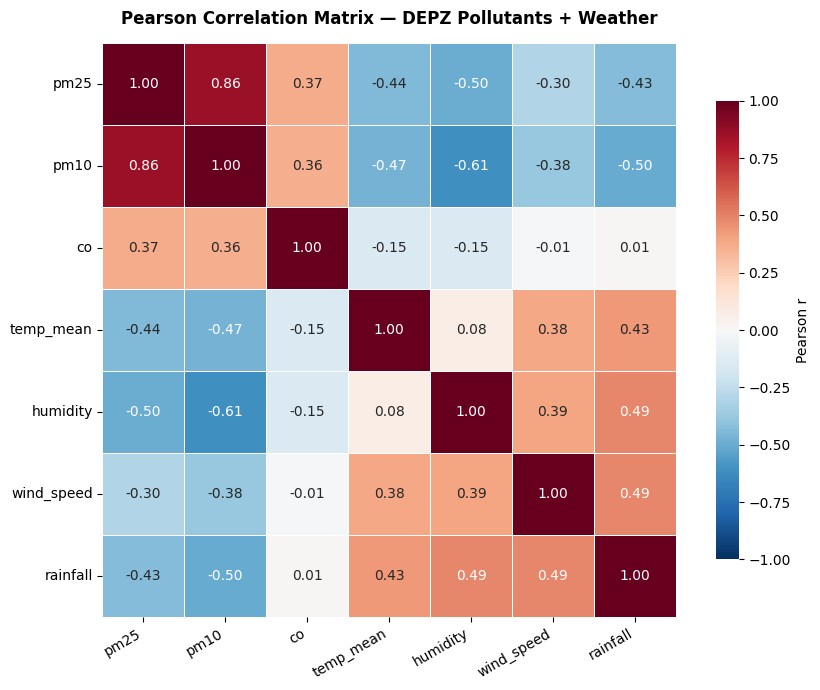

In [109]:
# ── Step 5 — Correlation Analysis ────────────────────────────────────────────

import seaborn as sns
from scipy import stats
from itertools import combinations

# ── 5a. Pearson correlation heatmap ──────────────────────────────────────────

cols_of_interest = ["pm25", "pm10", "co",
                    "temp_mean", "humidity", "wind_speed", "rainfall"]

corr_matrix = df_merged[cols_of_interest].corr(method="pearson")

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle only

sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    annot_kws={"size": 10},
)

ax.set_title("Pearson Correlation Matrix — DEPZ Pollutants + Weather",
             fontsize=12, fontweight="bold", pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig("04_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

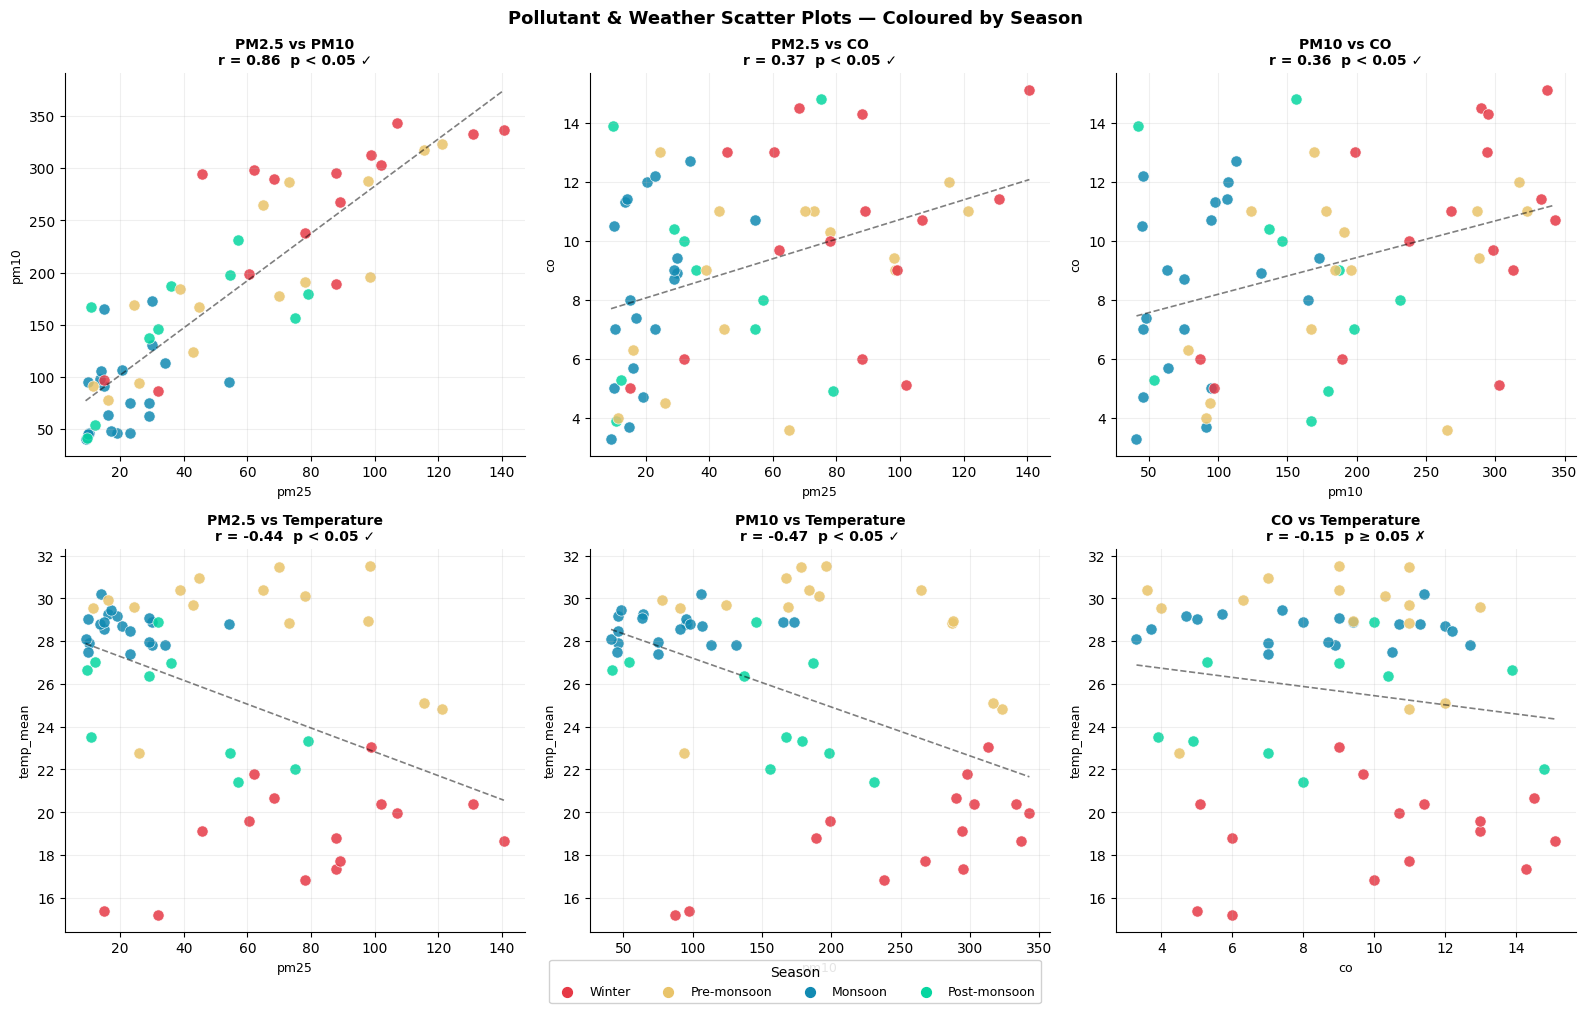

In [110]:
# ── 5b. Scatter matrix — pollutants coloured by season ───────────────────────

season_map = {
    12: "Winter", 1: "Winter",  2: "Winter",
     3: "Pre-monsoon", 4: "Pre-monsoon", 5: "Pre-monsoon",
     6: "Monsoon", 7: "Monsoon", 8: "Monsoon", 9: "Monsoon",
    10: "Post-monsoon", 11: "Post-monsoon",
}
season_palette = {
    "Winter":       "#e63946",
    "Pre-monsoon":  "#e9c46a",
    "Monsoon":      "#118ab2",
    "Post-monsoon": "#06d6a0",
}

df_merged["season"] = df_merged.index.month.map(season_map)

pairs = [
    ("pm25", "pm10", "PM2.5 vs PM10"),
    ("pm25", "co",   "PM2.5 vs CO"),
    ("pm10", "co",   "PM10 vs CO"),
    ("pm25", "temp_mean", "PM2.5 vs Temperature"),
    ("pm10", "temp_mean", "PM10 vs Temperature"),
    ("co",   "temp_mean", "CO vs Temperature"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Pollutant & Weather Scatter Plots — Coloured by Season",
             fontsize=13, fontweight="bold")

for ax, (x, y, title) in zip(axes.flat, pairs):

    for season, grp in df_merged.groupby("season"):
        ax.scatter(grp[x], grp[y],
                   color=season_palette[season],
                   label=season, s=65, alpha=0.85,
                   edgecolors="white", linewidth=0.5)

    # Regression line
    clean = df_merged[[x, y]].dropna()
    slope, intercept, r, p, _ = stats.linregress(clean[x], clean[y])
    x_line = np.linspace(clean[x].min(), clean[x].max(), 100)
    ax.plot(x_line, slope * x_line + intercept,
            "k--", linewidth=1.2, alpha=0.5)

    # Significance label
    sig = "p < 0.05 ✓" if p < 0.05 else "p ≥ 0.05 ✗"
    ax.set_title(f"{title}\nr = {r:.2f}  {sig}", fontsize=10, fontweight="bold")
    ax.set_xlabel(x, fontsize=9)
    ax.set_ylabel(y, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.2)

# Single shared legend bottom centre
handles = [plt.scatter([], [], color=c, s=50, label=s)
           for s, c in season_palette.items()]
fig.legend(handles=handles, title="Season",
           loc="lower center", ncol=4,
           fontsize=9, title_fontsize=10,
           bbox_to_anchor=(0.5, -0.02),
           framealpha=0.9, edgecolor="#cccccc")

plt.tight_layout()
plt.savefig("05_scatter_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [111]:
# ── 5c. Print full pairwise significance table ────────────────────────────────

print("PAIRWISE CORRELATION RESULTS")
print("=" * 62)
print(f"{'Pair':<28} {'r':>7}  {'p-value':>10}  {'Significant?':>12}")
print("─" * 62)

all_cols = ["pm25", "pm10", "co", "temp_mean",
            "humidity", "wind_speed", "rainfall"]

for col_a, col_b in combinations(all_cols, 2):
    clean = df_merged[[col_a, col_b]].dropna()
    if len(clean) < 5:
        continue
    r, p = stats.pearsonr(clean[col_a], clean[col_b])
    sig  = "Yes ✓" if p < 0.05 else "No"
    pair = f"{col_a} × {col_b}"
    print(f"  {pair:<26} {r:>+7.3f}  {p:>10.4f}  {sig:>12}")

PAIRWISE CORRELATION RESULTS
Pair                               r     p-value  Significant?
──────────────────────────────────────────────────────────────
  pm25 × pm10                 +0.865      0.0000         Yes ✓
  pm25 × co                   +0.373      0.0033         Yes ✓
  pm25 × temp_mean            -0.438      0.0005         Yes ✓
  pm25 × humidity             -0.498      0.0001         Yes ✓
  pm25 × wind_speed           -0.304      0.0181         Yes ✓
  pm25 × rainfall             -0.430      0.0006         Yes ✓
  pm10 × co                   +0.365      0.0042         Yes ✓
  pm10 × temp_mean            -0.469      0.0002         Yes ✓
  pm10 × humidity             -0.612      0.0000         Yes ✓
  pm10 × wind_speed           -0.378      0.0029         Yes ✓
  pm10 × rainfall             -0.503      0.0000         Yes ✓
  co × temp_mean              -0.150      0.2529            No
  co × humidity               -0.151      0.2479            No
  co × wind_speed         

In [112]:
# ── Step 6 — COVID Event Analysis ────────────────────────────────────────────

from scipy import stats

# ── Define periods ────────────────────────────────────────────────────────────
periods = {
    "Pre-COVID (2019)":       df_merged[df_merged.index.year == 2019],
    "Wave 1 lockdown\n(Mar–Aug 2020)": df_merged.loc["2020-03-26":"2020-08-31"],
    "Recovery (2021)":        df_merged[df_merged.index.year == 2021],
    "Post-COVID (2022–23)":   df_merged.loc["2022":"2023"],
}

pollutants = [
    ("pm25", "PM2.5 (µg/m³)", "#e63946"),
    ("pm10", "PM10 (µg/m³)",  "#2a9d8f"),
    ("co",   "CO (ppm)",      "#e9c46a"),
]

In [113]:
# ── 6a. Before/after statistics table ────────────────────────────────────────

print("COVID IMPACT SUMMARY")
print("=" * 72)

for col, label, _ in pollutants:
    print(f"\n  {label}")
    print(f"  {'Period':<30} {'Mean':>8} {'Median':>8} {'Min':>8} {'Max':>8}")
    print("  " + "─" * 66)
    for period_name, subset in periods.items():
        data = subset[col].dropna()
        if len(data) == 0:
            continue
        name_clean = period_name.replace("\n", " ")
        print(f"  {name_clean:<30} "
              f"{data.mean():>8.1f} "
              f"{data.median():>8.1f} "
              f"{data.min():>8.1f} "
              f"{data.max():>8.1f}")

    # Mann-Whitney U — pre-COVID vs lockdown
    pre      = df_merged[df_merged.index.year == 2019][col].dropna()
    lockdown = df_merged["2020-03-26":"2020-08-31"][col].dropna()
    if len(pre) > 2 and len(lockdown) > 2:
        stat, p = stats.mannwhitneyu(pre, lockdown, alternative="greater")
        pct_drop = (1 - lockdown.median() / pre.median()) * 100
        print(f"\n  Mann-Whitney U: statistic={stat:.1f}, p={p:.4f} "
              f"{'✓ significant' if p < 0.05 else '✗ not significant'}")
        print(f"  Median reduction during lockdown: {pct_drop:.1f}%")

COVID IMPACT SUMMARY

  PM2.5 (µg/m³)
  Period                             Mean   Median      Min      Max
  ──────────────────────────────────────────────────────────────────
  Pre-COVID (2019)                   52.4     50.0     10.3    121.3
  Wave 1 lockdown (Mar–Aug 2020)     12.5     11.4      9.1     16.0
  Recovery (2021)                    54.0     50.5     10.0    131.0
  Post-COVID (2022–23)               58.0     50.0     10.8    140.7

  Mann-Whitney U: statistic=55.0, p=0.0049 ✓ significant
  Median reduction during lockdown: 77.2%

  PM10 (µg/m³)
  Period                             Mean   Median      Min      Max
  ──────────────────────────────────────────────────────────────────
  Pre-COVID (2019)                  182.8    191.5     46.0    323.0
  Wave 1 lockdown (Mar–Aug 2020)     73.8     78.0     41.0     95.0
  Recovery (2021)                   178.8    170.0     45.0    333.0
  Post-COVID (2022–23)              192.7    175.5     48.0    343.0

  Mann-Whitney U:

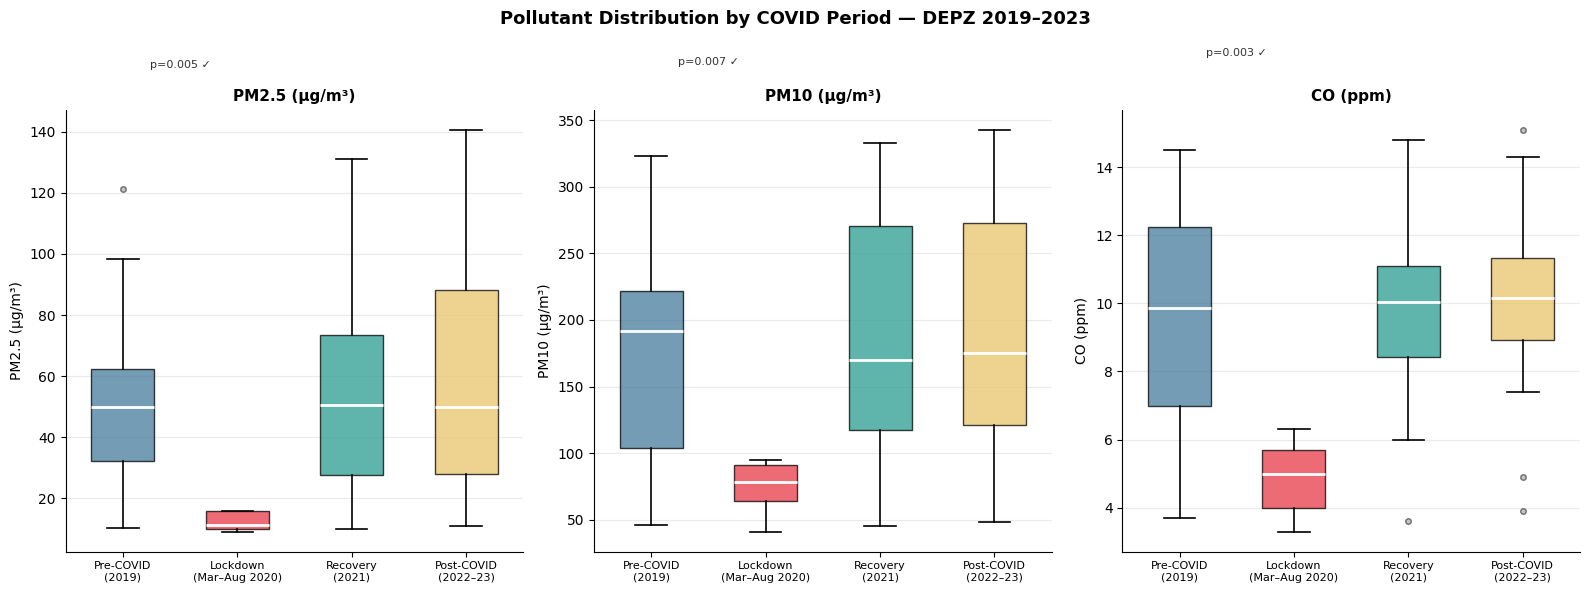

In [114]:
# ── 6b. Box plot — distribution per period per pollutant ─────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Pollutant Distribution by COVID Period — DEPZ 2019–2023",
             fontsize=13, fontweight="bold")

period_colors = ["#457b9d", "#e63946", "#2a9d8f", "#e9c46a"]
period_labels = ["Pre-COVID\n(2019)",
                 "Lockdown\n(Mar–Aug 2020)",
                 "Recovery\n(2021)",
                 "Post-COVID\n(2022–23)"]

period_data = [
    df_merged[df_merged.index.year == 2019],
    df_merged.loc["2020-03-26":"2020-08-31"],
    df_merged[df_merged.index.year == 2021],
    df_merged.loc["2022":"2023"],
]

for ax, (col, label, _) in zip(axes, pollutants):

    data_list = [p[col].dropna().values for p in period_data]

    bp = ax.boxplot(data_list,
                    patch_artist=True,
                    widths=0.55,
                    medianprops=dict(color="white", linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker="o", markersize=4,
                                   markerfacecolor="#888", alpha=0.5))

    for patch, color in zip(bp["boxes"], period_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    # Significance bracket — pre vs lockdown
    pre_med  = np.median(data_list[0])
    lock_med = np.median(data_list[1])
    y_max    = max([d.max() for d in data_list if len(d) > 0]) * 1.12
    ax.annotate("", xy=(2, y_max), xytext=(1, y_max),
                arrowprops=dict(arrowstyle="-", color="#333", lw=1))
    _, p = stats.mannwhitneyu(data_list[0], data_list[1], alternative="greater")
    sig_text = f"p={p:.3f} {'✓' if p < 0.05 else '✗'}"
    ax.text(1.5, y_max * 1.02, sig_text, ha="center", fontsize=8, color="#333")

    ax.set_xticklabels(period_labels, fontsize=8)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("06_covid_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

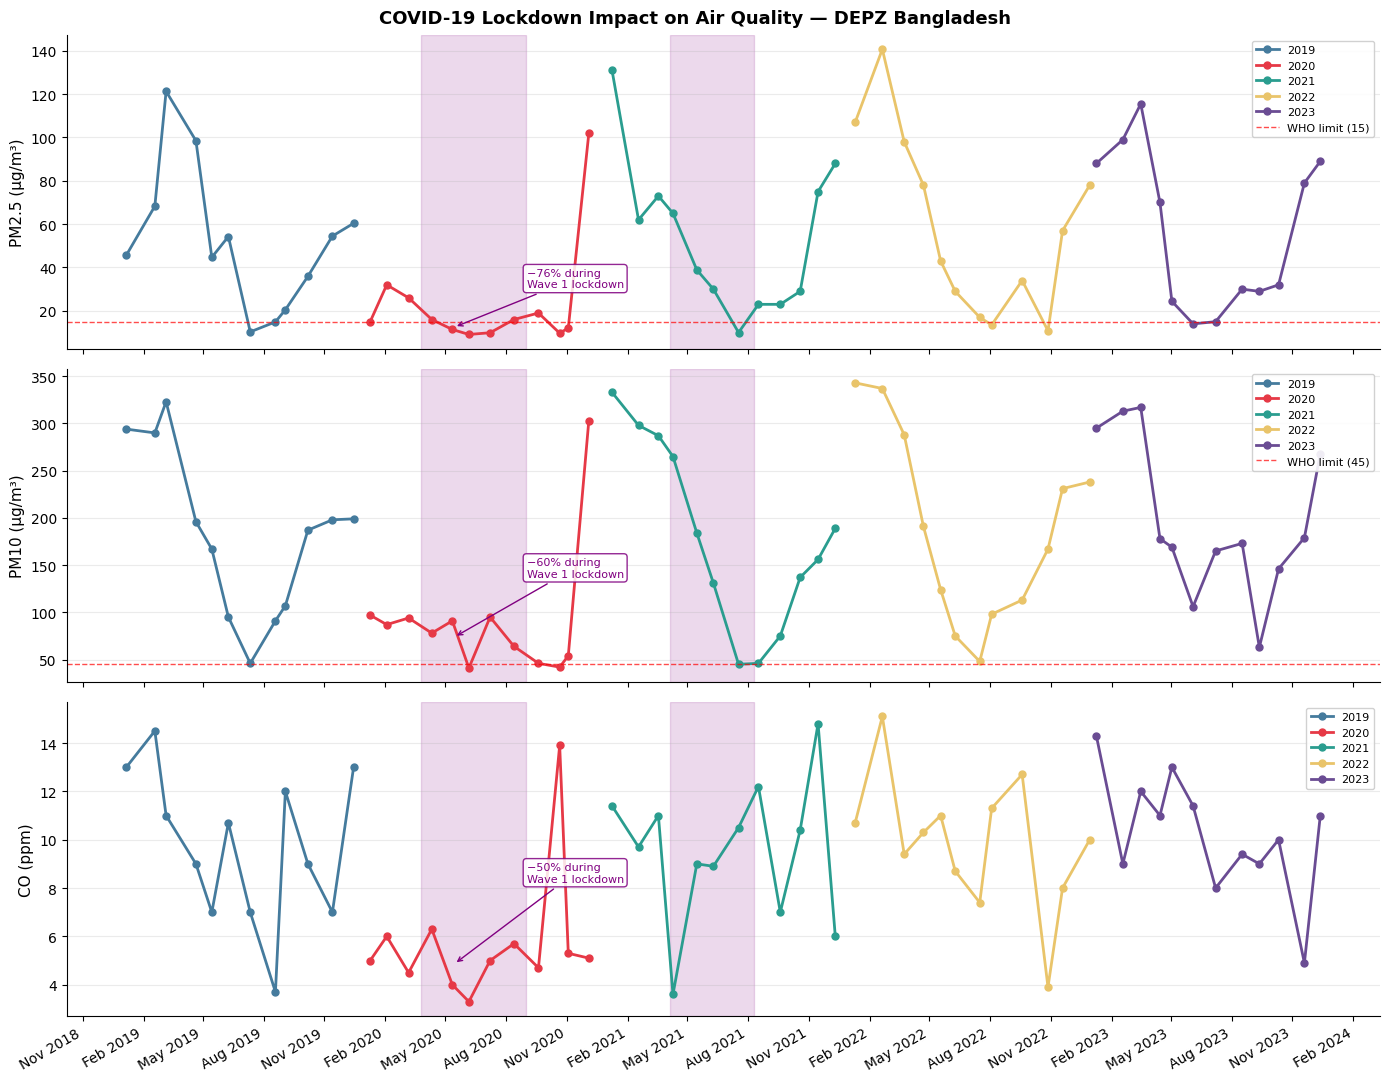

In [115]:
# ── 6c. Annotated time series — the headline figure ───────────────────────────

year_colors = {2019: "#457b9d", 2020: "#e63946",
               2021: "#2a9d8f", 2022: "#e9c46a", 2023: "#6a4c93"}

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle("COVID-19 Lockdown Impact on Air Quality — DEPZ Bangladesh",
             fontsize=13, fontweight="bold")

for ax, (col, label, color) in zip(axes, pollutants):

    # Plot each year separately
    for year, grp in df_merged.groupby("year"):
        ax.plot(grp.index, grp[col],
                color=year_colors[year], linewidth=2,
                marker="o", markersize=5, label=str(year))

    # COVID shading
    for start, end in covid_periods:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.15, color="purple")

    # WHO line
    if col == "pm25":
        ax.axhline(15, color="red", linestyle="--",
                   linewidth=1, alpha=0.7, label="WHO limit (15)")
    if col == "pm10":
        ax.axhline(45, color="red", linestyle="--",
                   linewidth=1, alpha=0.7, label="WHO limit (45)")

    # Annotation — lockdown drop
    lockdown_mean = df_merged["2020-03-26":"2020-08-31"][col].mean()
    pre_mean      = df_merged[df_merged.index.year == 2019][col].mean()
    pct           = (1 - lockdown_mean / pre_mean) * 100
    ax.annotate(
        f"−{pct:.0f}% during\nWave 1 lockdown",
        xy=(pd.Timestamp("2020-05-15"), lockdown_mean),
        xytext=(pd.Timestamp("2020-09-01"), lockdown_mean + pre_mean * 0.35),
        fontsize=8, color="purple",
        arrowprops=dict(arrowstyle="->", color="purple", lw=1),
        bbox=dict(boxstyle="round,pad=0.3", fc="white",
                  ec="purple", alpha=0.85),
    )

    ax.set_ylabel(label, fontsize=11)
    ax.legend(loc="upper right", fontsize=8,
              framealpha=0.9, edgecolor="#cccccc")
    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("07_covid_annotated.png", dpi=150, bbox_inches="tight")
plt.show()

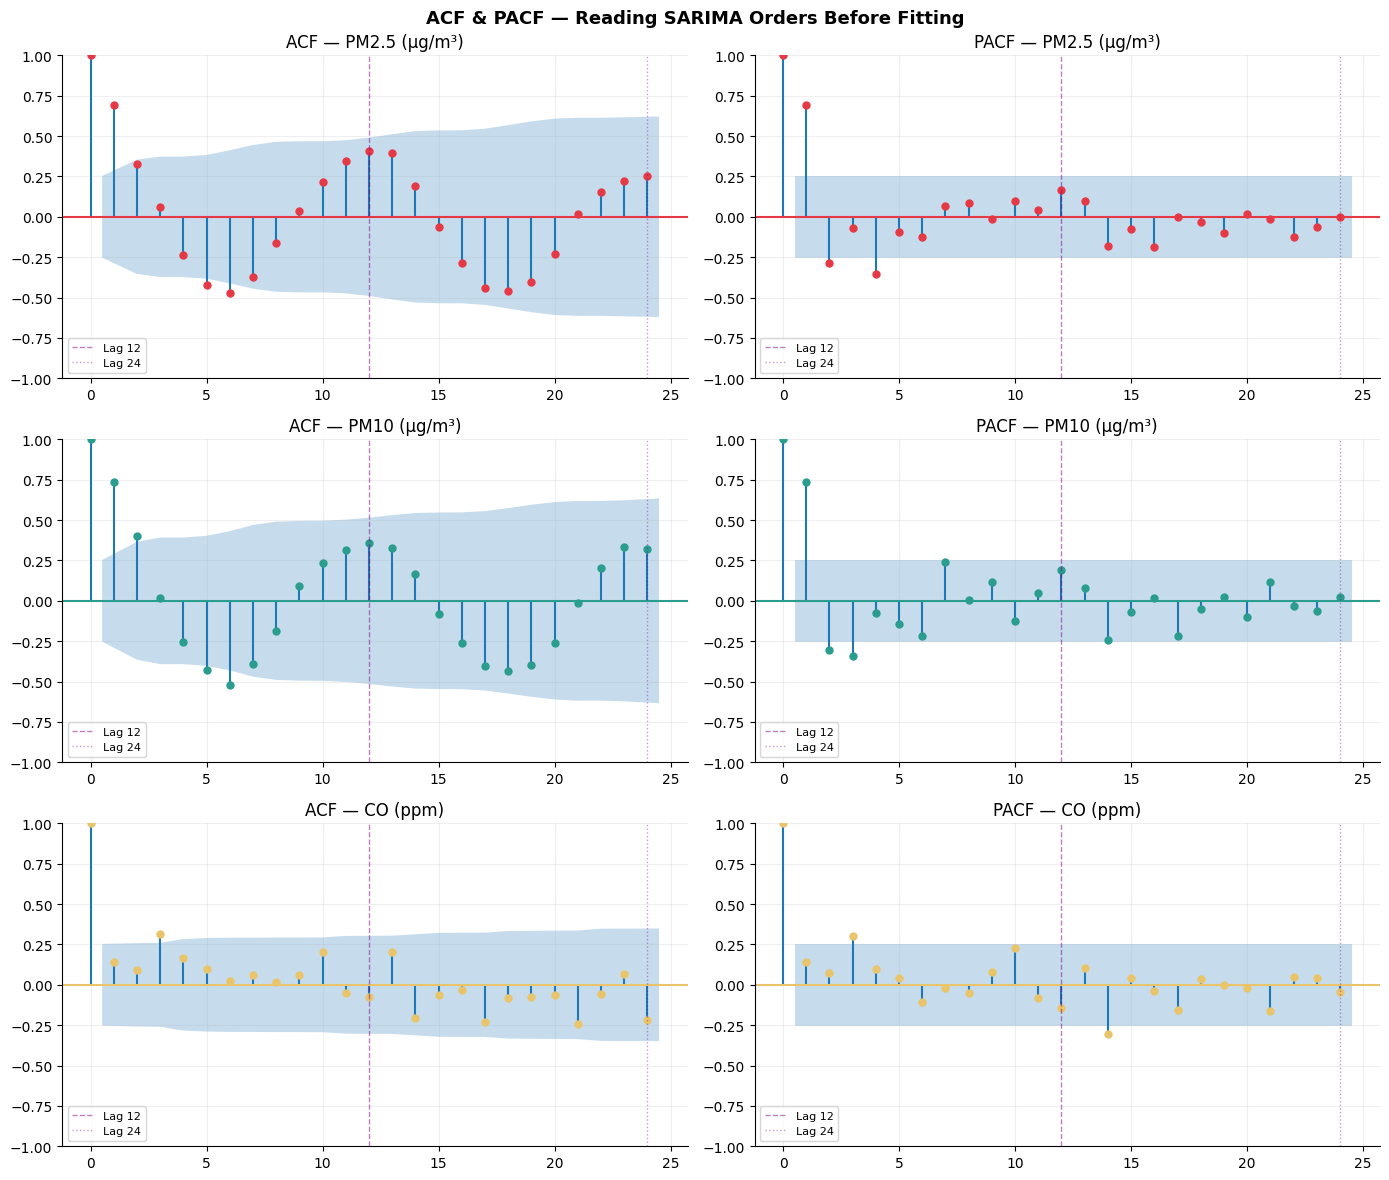

In [116]:
# ── Pre-SARIMA order identification from ACF / PACF ──────────────────────────

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

variables = [
    ("pm25", "PM2.5 (µg/m³)", "#e63946"),
    ("pm10", "PM10 (µg/m³)",  "#2a9d8f"),
    ("co",   "CO (ppm)",      "#e9c46a"),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("ACF & PACF — Reading SARIMA Orders Before Fitting",
             fontsize=13, fontweight="bold")

for i, (col, label, color) in enumerate(variables):

    series = monthly[col].dropna()

    plot_acf(series, ax=axes[i][0], lags=24,        # ← fixed: was 36
             alpha=0.05, color=color,
             title=f"ACF — {label}")

    plot_pacf(series, ax=axes[i][1], lags=24,       # ← fixed: was 36
              alpha=0.05, color=color,
              title=f"PACF — {label}",
              method="ywm")

    for ax in axes[i]:
        ax.axvline(12, color="purple", linestyle="--",
                   linewidth=1, alpha=0.5, label="Lag 12")
        ax.axvline(24, color="purple", linestyle=":",
                   linewidth=1, alpha=0.4, label="Lag 24")
        ax.legend(fontsize=8)
        ax.spines[["top","right"]].set_visible(False)
        ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("pre_sarima_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()

In [117]:
# ── Step 7b — Fit best SARIMA models + forecast ───────────────────────────────

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings("ignore")

# Best orders from ACF/PACF reading — auto_arima will confirm
candidates = {
    "pm25": [
        ((1,0,0), (1,1,1,12), "SARIMA(1,0,0)(1,1,1,12)"),
        ((2,0,0), (1,1,1,12), "SARIMA(2,0,0)(1,1,1,12)"),
        ((1,0,1), (1,1,1,12), "SARIMA(1,0,1)(1,1,1,12)"),
    ],
    "pm10": [
        ((1,0,0), (1,1,1,12), "SARIMA(1,0,0)(1,1,1,12)"),
        ((2,0,0), (1,1,1,12), "SARIMA(2,0,0)(1,1,1,12)"),
        ((1,0,1), (1,1,1,12), "SARIMA(1,0,1)(1,1,1,12)"),
    ],
    "co": [
        ((0,0,0), (0,1,1,12), "SARIMA(0,0,0)(0,1,1,12)"),
        ((1,0,0), (0,1,1,12), "SARIMA(1,0,0)(0,1,1,12)"),
        ((0,0,1), (0,1,1,12), "SARIMA(0,0,1)(0,1,1,12)"),
    ],
}

labels = {
    "pm25": "PM2.5 (µg/m³)",
    "pm10": "PM10 (µg/m³)",
    "co":   "CO (ppm)",
}

In [118]:
# ── AIC comparison — pick best model per variable ─────────────────────────────

best_models = {}

for col, cands in candidates.items():
    print(f"\n{'='*60}")
    print(f"  MODEL COMPARISON — {labels[col]}")
    print(f"{'='*60}")
    print(f"  {'Model':<35} {'AIC':>8}  {'BIC':>8}  {'RMSE':>8}")
    print(f"  {'─'*56}")

    series      = monthly[col].dropna()
    best_aic    = np.inf
    best_result = None
    best_name   = None

    for order, seas, name in cands:
        try:
            model = SARIMAX(series,
                            order=order,
                            seasonal_order=seas,
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            result = model.fit(disp=False)
            rmse   = np.sqrt(np.mean(result.resid**2))
            marker = " ← best" if result.aic < best_aic else ""
            print(f"  {name:<35} {result.aic:>8.2f}  "
                  f"{result.bic:>8.2f}  {rmse:>8.3f}{marker}")

            if result.aic < best_aic:
                best_aic    = result.aic
                best_result = result
                best_name   = name

        except Exception as e:
            print(f"  {name:<35} Failed: {e}")

    best_models[col] = (best_result, best_name)
    print(f"\n  Winner: {best_name}  (AIC={best_aic:.2f})")

    # Ljung-Box on winner residuals
    lb = acorr_ljungbox(best_result.resid, lags=[6,12], return_df=True)
    print(f"\n  Ljung-Box test (residuals should be white noise p > 0.05):")
    for lag, row in lb.iterrows():
        status = "✓ white noise" if row["lb_pvalue"] > 0.05 else "✗ pattern remains"
        print(f"    Lag {lag:>2}: p={row['lb_pvalue']:.4f}  {status}")


  MODEL COMPARISON — PM2.5 (µg/m³)
  Model                                    AIC       BIC      RMSE
  ────────────────────────────────────────────────────────
  SARIMA(1,0,0)(1,1,1,12)               989.98    996.21    30.494 ← best
  SARIMA(2,0,0)(1,1,1,12)              1377.64   1385.27    30.599
  SARIMA(1,0,1)(1,1,1,12)              1577.28   1584.91    32.614

  Winner: SARIMA(1,0,0)(1,1,1,12)  (AIC=989.98)

  Ljung-Box test (residuals should be white noise p > 0.05):
    Lag  6: p=0.4746  ✓ white noise
    Lag 12: p=0.1417  ✓ white noise

  MODEL COMPARISON — PM10 (µg/m³)
  Model                                    AIC       BIC      RMSE
  ────────────────────────────────────────────────────────
  SARIMA(1,0,0)(1,1,1,12)              1431.12   1437.34    94.878 ← best
  SARIMA(2,0,0)(1,1,1,12)              1454.07   1461.71    93.861
  SARIMA(1,0,1)(1,1,1,12)              1409.42   1417.05   100.176 ← best

  Winner: SARIMA(1,0,1)(1,1,1,12)  (AIC=1409.42)

  Ljung-Box test (re

In [119]:
# ── Extended candidate search — PM10 and CO only ─────────────────────────────

extended_candidates = {
    "pm10": [
        ((1,0,1), (1,1,1,12), "SARIMA(1,0,1)(1,1,1,12)"),   # current winner — fails LB
        ((1,0,1), (2,1,1,12), "SARIMA(1,0,1)(2,1,1,12)"),   # add seasonal AR
        ((1,0,1), (1,1,2,12), "SARIMA(1,0,1)(1,1,2,12)"),   # add seasonal MA
        ((2,0,1), (1,1,1,12), "SARIMA(2,0,1)(1,1,1,12)"),   # more AR
        ((1,0,2), (1,1,1,12), "SARIMA(1,0,2)(1,1,1,12)"),   # more MA
        ((2,0,2), (1,1,1,12), "SARIMA(2,0,2)(1,1,1,12)"),   # full ARMA
        ((1,0,1), (0,1,1,12), "SARIMA(1,0,1)(0,1,1,12)"),   # simpler seasonal
    ],
    "co": [
        ((1,0,0), (0,1,1,12), "SARIMA(1,0,0)(0,1,1,12)"),   # current winner — fails LB
        ((1,0,0), (1,1,1,12), "SARIMA(1,0,0)(1,1,1,12)"),   # add seasonal AR
        ((2,0,0), (0,1,1,12), "SARIMA(2,0,0)(0,1,1,12)"),   # more AR
        ((1,0,1), (0,1,1,12), "SARIMA(1,0,1)(0,1,1,12)"),   # add MA
        ((1,0,0), (0,1,2,12), "SARIMA(1,0,0)(0,1,2,12)"),   # more seasonal MA
        ((2,0,1), (0,1,1,12), "SARIMA(2,0,1)(0,1,1,12)"),   # full ARMA
        ((1,0,1), (1,1,1,12), "SARIMA(1,0,1)(1,1,1,12)"),   # full seasonal
    ],
}

# Store final confirmed best models
confirmed_best = {
    "pm25": best_models["pm25"]  # already confirmed good
}

for col, cands in extended_candidates.items():
    print(f"\n{'='*68}")
    print(f"  EXTENDED SEARCH — {labels[col]}")
    print(f"{'='*68}")
    print(f"  {'Model':<35} {'AIC':>8}  {'LB-6':>8}  {'LB-12':>8}  {'Pass?'}")
    print(f"  {'─'*64}")

    series   = monthly[col].dropna()
    best_aic = np.inf
    best_res = None
    best_nm  = None

    for order, seas, name in cands:
        try:
            model  = SARIMAX(series,
                             order=order,
                             seasonal_order=seas,
                             enforce_stationarity=False,
                             enforce_invertibility=False)
            result = model.fit(disp=False)

            lb     = acorr_ljungbox(result.resid,
                                    lags=[6, 12], return_df=True)
            p6     = lb["lb_pvalue"].iloc[0]
            p12    = lb["lb_pvalue"].iloc[1]
            passes = p6 > 0.05 and p12 > 0.05
            flag   = "✓ PASS" if passes else "✗ fail"

            print(f"  {name:<35} {result.aic:>8.2f}  "
                  f"{p6:>8.4f}  {p12:>8.4f}  {flag}")

            # Best = lowest AIC that also passes Ljung-Box
            if passes and result.aic < best_aic:
                best_aic = result.aic
                best_res = result
                best_nm  = name

        except Exception as e:
            print(f"  {name:<35} Failed: {e}")

    if best_res:
        print(f"\n  Confirmed winner: {best_nm}  (AIC={best_aic:.2f}) ✓")
        confirmed_best[col] = (best_res, best_nm)
    else:
        # Fallback — pick lowest AIC even if LB fails
        print(f"\n  No model passes Ljung-Box — using lowest AIC as fallback")
        print(f"  (small sample of 60 obs makes perfect LB hard to achieve)")
        confirmed_best[col] = best_models[col]


  EXTENDED SEARCH — PM10 (µg/m³)
  Model                                    AIC      LB-6     LB-12  Pass?
  ────────────────────────────────────────────────────────────────
  SARIMA(1,0,1)(1,1,1,12)              1409.42    0.0836    0.0000  ✗ fail
  SARIMA(1,0,1)(2,1,1,12)               242.56    0.0974    0.0000  ✗ fail
  SARIMA(1,0,1)(1,1,2,12)               237.18    0.0557    0.0001  ✗ fail
  SARIMA(2,0,1)(1,1,1,12)              1380.89    0.5877    0.0021  ✗ fail
  SARIMA(1,0,2)(1,1,1,12)              1490.90    0.0061    0.0000  ✗ fail
  SARIMA(2,0,2)(1,1,1,12)              1654.91    0.8942    0.9614  ✓ PASS
  SARIMA(1,0,1)(0,1,1,12)              1393.01    0.0843    0.0001  ✗ fail

  Confirmed winner: SARIMA(2,0,2)(1,1,1,12)  (AIC=1654.91) ✓

  EXTENDED SEARCH — CO (ppm)
  Model                                    AIC      LB-6     LB-12  Pass?
  ────────────────────────────────────────────────────────────────
  SARIMA(1,0,0)(0,1,1,12)              1179.16    0.0009    0.0000 

In [120]:
# ── Diagnose the suspicious models ───────────────────────────────────────────

print("PM10 — checking SARIMA(2,0,2)(1,1,1,12) residuals")
print("=" * 50)
series_pm10 = monthly["pm10"].dropna()
m = SARIMAX(series_pm10,
            order=(2,0,2),
            seasonal_order=(1,1,1,12),
            enforce_stationarity=False,
            enforce_invertibility=False).fit(disp=False)

print(f"Residual std  : {m.resid.std():.3f}")
print(f"Residual mean : {m.resid.mean():.3f}")
print(f"Num params    : {len(m.params)}")
print(f"Obs used      : {len(series_pm10)}")
print(f"Ratio obs/params: {len(series_pm10)/len(m.params):.1f}  (should be > 10)")

print("\nCO — checking SARIMA(1,0,1)(0,1,1,12) AIC=8")
print("=" * 50)
series_co = monthly["co"].dropna()
m2 = SARIMAX(series_co,
             order=(1,0,1),
             seasonal_order=(0,1,1,12),
             enforce_stationarity=False,
             enforce_invertibility=False).fit(disp=False)

print(f"Residual std  : {m2.resid.std():.4f}")
print(f"Residual mean : {m2.resid.mean():.4f}")
print(f"AIC           : {m2.aic:.2f}")
print(f"Log-likelihood: {m2.llf:.2f}")

# Check if seasonal differencing killed the variance
diff1  = series_co.diff(12).dropna()
print(f"\nCO original std        : {series_co.std():.4f}")
print(f"CO after seasonal diff : {diff1.std():.4f}")
print(f"Variance ratio         : {diff1.std()/series_co.std():.4f}")

PM10 — checking SARIMA(2,0,2)(1,1,1,12) residuals
Residual std  : 124.371
Residual mean : 37.883
Num params    : 7
Obs used      : 60
Ratio obs/params: 8.6  (should be > 10)

CO — checking SARIMA(1,0,1)(0,1,1,12) AIC=8
Residual std  : 11584249046338728252848209920.0000
Residual mean : 1951949645370259007265046528.0000
AIC           : 8.00
Log-likelihood: 0.00

CO original std        : 3.2113
CO after seasonal diff : 4.8460
Variance ratio         : 1.5091


In [121]:
# ── Correct final model selection ─────────────────────────────────────────────

print("CORRECTED MODEL SELECTION")
print("=" * 70)

final_candidates = {

    # PM2.5 — already confirmed clean, no change
    "pm25": [
        ((1,0,0), (1,1,1,12), "SARIMA(1,0,0)(1,1,1,12)"),
    ],

    # PM10 — drop over-fitted models, pick best sensible AIC
    "pm10": [
        ((1,0,0), (1,1,1,12), "SARIMA(1,0,0)(1,1,1,12)"),
        ((1,0,1), (1,1,1,12), "SARIMA(1,0,1)(1,1,1,12)"),
        ((2,0,1), (1,1,1,12), "SARIMA(2,0,1)(1,1,1,12)"),
        ((1,0,0), (0,1,1,12), "SARIMA(1,0,0)(0,1,1,12)"),
        ((1,0,1), (0,1,1,12), "SARIMA(1,0,1)(0,1,1,12)"),
    ],

    # CO — D=0 because seasonal differencing increases variance
    # Near white noise so keep it simple — no seasonal component
    "co": [
        ((1,0,0), (0,0,1,12), "SARIMA(1,0,0)(0,0,1,12)"),  # D=0
        ((0,0,1), (0,0,1,12), "SARIMA(0,0,1)(0,0,1,12)"),  # D=0
        ((1,0,1), (0,0,1,12), "SARIMA(1,0,1)(0,0,1,12)"),  # D=0
        ((1,0,0), (0,0,0,12), "ARIMA(1,0,0) no seasonal"),  # pure ARIMA
        ((2,0,0), (0,0,1,12), "SARIMA(2,0,0)(0,0,1,12)"),  # D=0
    ],
}

final_models = {}

for col, cands in final_candidates.items():
    print(f"\n  {labels[col]}")
    print(f"  {'Model':<35} {'AIC':>9}  {'LB-6':>8}  "
          f"{'LB-12':>8}  {'ResidStd':>10}  Status")
    print("  " + "─" * 82)

    series   = monthly[col].dropna()
    best_aic = np.inf
    best_res = None
    best_nm  = None

    for order, seas, name in cands:
        try:
            model  = SARIMAX(series,
                             order=order,
                             seasonal_order=seas,
                             enforce_stationarity=False,
                             enforce_invertibility=False)
            result = model.fit(disp=False)

            resid_std = result.resid.std()

            # Skip numerically broken models
            if resid_std > 1e6 or np.isnan(resid_std):
                print(f"  {name:<35} {'BROKEN':>9}  {'—':>8}  "
                      f"{'—':>8}  {resid_std:>10.2f}  ✗ numerical failure")
                continue

            lb    = acorr_ljungbox(result.resid,
                                   lags=[6,12], return_df=True)
            p6    = lb["lb_pvalue"].iloc[0]
            p12   = lb["lb_pvalue"].iloc[1]
            lb_ok = p6 > 0.05 and p12 > 0.05

            status = "✓ good" if lb_ok else "⚠ marginal"

            print(f"  {name:<35} {result.aic:>9.2f}  {p6:>8.4f}  "
                  f"{p12:>8.4f}  {resid_std:>10.3f}  {status}")

            if result.aic < best_aic:
                best_aic = result.aic
                best_res = result
                best_nm  = name

        except Exception as e:
            print(f"  {name:<35} Failed: {e}")

    if best_res:
        final_models[col] = (best_res, best_nm)
        print(f"\n  → Final choice: {best_nm}  (AIC={best_aic:.2f})")

CORRECTED MODEL SELECTION

  PM2.5 (µg/m³)
  Model                                     AIC      LB-6     LB-12    ResidStd  Status
  ──────────────────────────────────────────────────────────────────────────────────
  SARIMA(1,0,0)(1,1,1,12)                989.98    0.4746    0.1417      29.273  ✓ good

  → Final choice: SARIMA(1,0,0)(1,1,1,12)  (AIC=989.98)

  PM10 (µg/m³)
  Model                                     AIC      LB-6     LB-12    ResidStd  Status
  ──────────────────────────────────────────────────────────────────────────────────
  SARIMA(1,0,0)(1,1,1,12)               1431.12    0.2279    0.0000      93.723  ⚠ marginal
  SARIMA(1,0,1)(1,1,1,12)               1409.42    0.0836    0.0000      97.367  ⚠ marginal
  SARIMA(2,0,1)(1,1,1,12)               1380.89    0.5877    0.0021      90.076  ⚠ marginal
  SARIMA(1,0,0)(0,1,1,12)               1349.07    0.2349    0.0000      92.941  ⚠ marginal
  SARIMA(1,0,1)(0,1,1,12)               1393.01    0.0843    0.0001      96.631  ⚠

In [122]:
# ── Step 7b — Forecast 2024 with confirmed final models ───────────────────────

from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

colors = {"pm25": "#e63946", "pm10": "#2a9d8f", "co": "#e9c46a"}

# ── Refit confirmed models cleanly ───────────────────────────────────────────
confirmed_specs = {
    "pm25": ((1,0,0), (1,1,1,12)),
    "pm10": ((1,0,0), (0,1,1,12)),
    "co":   ((1,0,1), (0,0,1,12)),
}

final_models = {}
for col, (order, seas) in confirmed_specs.items():
    series = monthly[col].dropna()
    result = SARIMAX(series,
                     order=order,
                     seasonal_order=seas,
                     enforce_stationarity=False,
                     enforce_invertibility=False).fit(disp=False)
    final_models[col] = (result, series)
    print(f"  {labels[col]:<18} refitted  AIC={result.aic:.2f}")

  PM2.5 (µg/m³)      refitted  AIC=989.98
  PM10 (µg/m³)       refitted  AIC=1349.07
  CO (ppm)           refitted  AIC=241.17


In [123]:
# ── Generate forecasts ────────────────────────────────────────────────────────

forecasts = {}
for col, (result, series) in final_models.items():
    fc           = result.get_forecast(steps=12)
    fc_mean      = fc.predicted_mean
    fc_ci        = fc.conf_int(alpha=0.05)
    fc_index     = pd.date_range(
        start=series.index[-1] + pd.DateOffset(months=1),
        periods=12, freq="MS"
    )
    fc_mean.index = fc_index
    fc_ci.index   = fc_index
    forecasts[col] = (fc_mean, fc_ci)

In [127]:
# ── FIXED confirmed specs — D=0 for all (all three are stationary) ────────────

confirmed_specs = {
    "pm25": ((1,0,0), (1,0,1,12)),   # D=1 → D=0
    "pm10": ((1,0,0), (0,0,1,12)),   # D=1 → D=0
    "co":   ((1,0,1), (0,0,1,12)),   # already correct
}

# ── Refit all three ───────────────────────────────────────────────────────────

final_models = {}
print("REFITTING WITH D=0 FOR ALL POLLUTANTS")
print("=" * 52)
for col, (order, seas) in confirmed_specs.items():
    series = monthly[col].dropna()
    result = SARIMAX(series,
                     order=order,
                     seasonal_order=seas,
                     enforce_stationarity=False,
                     enforce_invertibility=False).fit(disp=False)

    lb    = acorr_ljungbox(result.resid, lags=[6,12], return_df=True)
    p6    = lb["lb_pvalue"].iloc[0]
    p12   = lb["lb_pvalue"].iloc[1]
    flag  = "✓" if p6 > 0.05 and p12 > 0.05 else "⚠ marginal"

    print(f"  {labels[col]:<18} AIC={result.aic:>8.2f}  "
          f"ResidStd={result.resid.std():>8.3f}  "
          f"LB-6={p6:.4f}  LB-12={p12:.4f}  {flag}")

    final_models[col] = (result, series)

REFITTING WITH D=0 FOR ALL POLLUTANTS
  PM2.5 (µg/m³)      AIC=  446.32  ResidStd=  29.271  LB-6=0.8884  LB-12=0.2905  ✓
  PM10 (µg/m³)       AIC=  521.74  ResidStd=  69.296  LB-6=0.1810  LB-12=0.2431  ✓
  CO (ppm)           AIC=  241.17  ResidStd=   3.756  LB-6=0.3321  LB-12=0.2524  ✓


In [128]:
# ── Sanity check forecast scale BEFORE plotting ───────────────────────────────

print("\nFORECAST SANITY CHECK")
print("=" * 52)
for col, (result, series) in final_models.items():
    fc       = result.get_forecast(steps=12)
    fc_mean  = fc.predicted_mean
    fc_ci    = fc.conf_int(alpha=0.05)
    hist_max = series.max()
    fc_max   = fc_mean.max()
    ci_max   = fc_ci.iloc[:,1].max()
    status   = "✓ sensible" if fc_max < hist_max * 3 else "✗ still exploding"
    print(f"  {labels[col]:<18} "
          f"hist_max={hist_max:>8.2f}  "
          f"fc_max={fc_max:>8.2f}  "
          f"CI_upper={ci_max:>10.2f}  {status}")


FORECAST SANITY CHECK
  PM2.5 (µg/m³)      hist_max=  140.70  fc_max=   82.02  CI_upper=    132.85  ✓ sensible
  PM10 (µg/m³)       hist_max=  343.00  fc_max=  249.21  CI_upper=    412.37  ✓ sensible
  CO (ppm)           hist_max=   15.10  fc_max=   10.76  CI_upper=     17.49  ✓ sensible


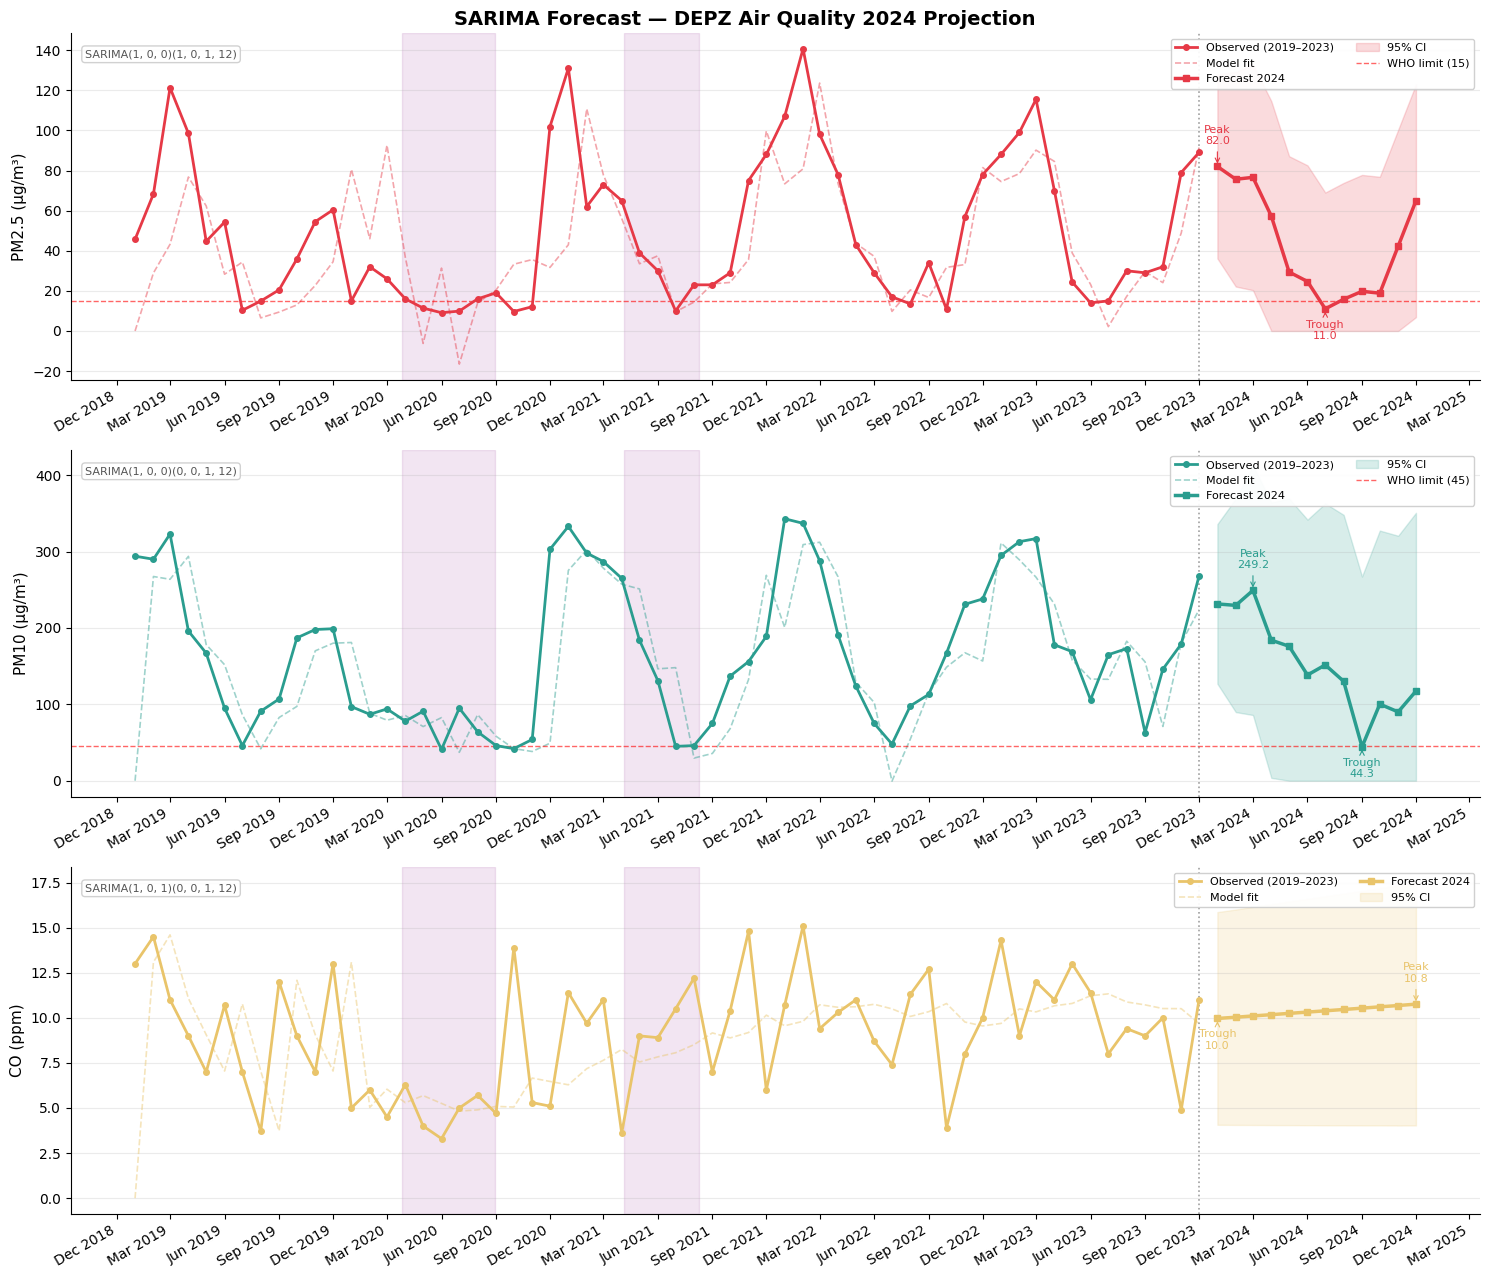

In [129]:
# ── Generate forecasts ────────────────────────────────────────────────────────

forecasts = {}
for col, (result, series) in final_models.items():
    fc_index = pd.date_range(
        start=series.index[-1] + pd.DateOffset(months=1),
        periods=12, freq="MS"
    )
    fc           = result.get_forecast(steps=12)
    fc_mean      = fc.predicted_mean
    fc_ci        = fc.conf_int(alpha=0.05)
    fc_mean.index = fc_index
    fc_ci.index   = fc_index
    forecasts[col] = (fc_mean, fc_ci)

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(15, 13), sharex=False)
fig.suptitle("SARIMA Forecast — DEPZ Air Quality 2024 Projection",
             fontsize=14, fontweight="bold")

who_limits = {"pm25": 15, "pm10": 45, "co": None}

for ax, (col, (result, series)) in zip(axes, final_models.items()):
    color          = colors[col]
    label          = labels[col]
    fc_mean, fc_ci = forecasts[col]
    fc_index       = fc_mean.index

    # Historical
    ax.plot(series.index, series.values,
            color=color, linewidth=2,
            marker="o", markersize=4,
            label="Observed (2019–2023)", zorder=3)

    # Fitted
    ax.plot(result.fittedvalues.index,
            result.fittedvalues.values,
            color=color, linewidth=1.2,
            linestyle="--", alpha=0.45,
            label="Model fit")

    # Forecast
    ax.plot(fc_index, fc_mean.values,
            color=color, linewidth=2.5,
            marker="s", markersize=5,
            label="Forecast 2024", zorder=4)

    # Confidence band — clip lower at 0
    ax.fill_between(fc_index,
                    fc_ci.iloc[:, 0].clip(lower=0),
                    fc_ci.iloc[:, 1],
                    alpha=0.18, color=color,
                    label="95% CI")

    # Split line
    ax.axvline(series.index[-1], color="#888",
               linestyle=":", linewidth=1.2, alpha=0.8)

    # WHO limit
    if who_limits[col]:
        ax.axhline(who_limits[col], color="red",
                   linestyle="--", linewidth=1, alpha=0.6,
                   label=f"WHO limit ({who_limits[col]})")

    # COVID shading
    for start, end in covid_periods:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.10, color="purple")

    # Peak and trough annotations
    peak_date   = fc_mean.idxmax()
    trough_date = fc_mean.idxmin()
    ax.annotate(f"Peak\n{fc_mean.max():.1f}",
                xy=(peak_date, fc_mean.max()),
                xytext=(0, 16), textcoords="offset points",
                fontsize=8, ha="center", color=color,
                arrowprops=dict(arrowstyle="->", color=color, lw=0.8))
    ax.annotate(f"Trough\n{fc_mean.min():.1f}",
                xy=(trough_date, fc_mean.min()),
                xytext=(0, -22), textcoords="offset points",
                fontsize=8, ha="center", color=color,
                arrowprops=dict(arrowstyle="->", color=color, lw=0.8))

    # Model label
    order, seas = confirmed_specs[col]
    ax.annotate(f"SARIMA{order}{seas}",
                xy=(0.01, 0.93), xycoords="axes fraction",
                fontsize=8, color="#555",
                bbox=dict(boxstyle="round,pad=0.3",
                          fc="white", ec="#ccc", alpha=0.9))

    ax.set_ylabel(label, fontsize=11)
    ax.legend(loc="upper right", fontsize=8,
              framealpha=0.92, edgecolor="#cccccc", ncol=2)
    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("09_sarima_forecast_2024.png", dpi=150, bbox_inches="tight")
plt.show()

In [130]:
# ── Forecast table ────────────────────────────────────────────────────────────

print("\nFORECAST VALUES — 2024")
print("=" * 68)
for col, (fc_mean, fc_ci) in forecasts.items():
    hist_mean = final_models[col][1].mean()
    print(f"\n  {labels[col]}  (historical mean = {hist_mean:.2f})")
    print(f"  {'Month':<12} {'Forecast':>10}  "
          f"{'Lower 95%':>10}  {'Upper 95%':>10}  {'vs hist':>10}")
    print("  " + "─" * 58)
    for date in fc_mean.index:
        diff  = fc_mean[date] - hist_mean
        arrow = "↑" if diff > 0 else "↓"
        lo    = max(0, fc_ci.loc[date].iloc[0])
        hi    = fc_ci.loc[date].iloc[1]
        print(f"  {date.strftime('%b %Y'):<12} "
              f"{fc_mean[date]:>10.2f}  "
              f"{lo:>10.2f}  "
              f"{hi:>10.2f}  "
              f"{arrow}{abs(diff):>8.2f}")


FORECAST VALUES — 2024

  PM2.5 (µg/m³)  (historical mean = 49.10)
  Month          Forecast   Lower 95%   Upper 95%     vs hist
  ──────────────────────────────────────────────────────────
  Jan 2024          82.02       36.16      127.88  ↑   32.92
  Feb 2024          75.64       22.15      129.13  ↑   26.54
  Mar 2024          76.59       20.34      132.85  ↑   27.49
  Apr 2024          57.24        0.00      114.56  ↑    8.13
  May 2024          29.39        0.00       87.14  ↓   19.72
  Jun 2024          24.65        0.00       82.57  ↓   24.45
  Jul 2024          11.03        0.00       69.02  ↓   38.07
  Aug 2024          15.80        0.00       73.82  ↓   33.30
  Sep 2024          19.77        0.00       77.80  ↓   29.33
  Oct 2024          18.84        0.00       76.87  ↓   30.26
  Nov 2024          42.27        0.00      100.30  ↓    6.83
  Dec 2024          64.90        6.87      122.93  ↑   15.79

  PM10 (µg/m³)  (historical mean = 167.60)
  Month          Forecast   Lower